# Lab 1 — Inside a Foundation Model

**Course:** Foundation Models: Architecture, Training and Alignment  
**Goal:** understand the basic pipeline: Text → Tokens → Embeddings → Attention → Output.

Run the cells, change the examples, and answer the reflection questions at the end.

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>מעבדה 1 — בתוך מודל יסוד</p>
<p>קורס: מודלי יסוד — ארכיטקטורה, אימון ויישור</p>
<p>מטרה: להבין את צינור העיבוד הבסיסי מטקסט לפלט:</p>
<p style="direction: ltr; text-align: left;">Text → Tokens → Embeddings → Attention → Output</p>
<p>יש להריץ את התאים לפי הסדר, לשנות את הדוגמאות, ולענות על שאלות הרפלקציה בסוף.</p>
<hr>
</div>

In [ ]:
!pip -q install transformers sentence-transformers scikit-learn matplotlib accelerate

## Part A — Tokenization

A model does not see words. It sees token IDs.

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>חלק א: Tokenization</p>
<p>בחלק זה נבחן כיצד טקסט רגיל הופך לרשימת טוקנים ולרשימת מספרים. שימו לב במיוחד למילים ארוכות, לטקסט בעברית, למספרים, לכתובות URL ולאימוג'י.</p>
<hr>
</div>

In [ ]:
from transformers import AutoTokenizer

bert_tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
gpt_tokenizer = AutoTokenizer.from_pretrained("gpt2")

texts = [
    "Transformers are amazing!",
    "internationalization",
    "The price is 39.99 dollars.",
    "https://www.example.com/foundation-models",
    "שלום עולם",
    "AI 🚀 is changing everything"
]

for text in texts:
    print("TEXT:", repr(text))
    print("BERT tokens:", bert_tokenizer.tokenize(text))
    print("BERT token count:", len(bert_tokenizer.tokenize(text)))
    print("GPT-2 tokens:", gpt_tokenizer.tokenize(text))
    print("GPT-2 token count:", len(gpt_tokenizer.tokenize(text)))

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

TEXT: 'Transformers are amazing!'
BERT tokens: ['transformers', 'are', 'amazing', '!']
BERT token count: 4
GPT-2 tokens: ['Transform', 'ers', 'Ġare', 'Ġamazing', '!']
GPT-2 token count: 5
TEXT: 'internationalization'
BERT tokens: ['international', '##ization']
BERT token count: 2
GPT-2 tokens: ['international', 'ization']
GPT-2 token count: 2
TEXT: 'The price is 39.99 dollars.'
BERT tokens: ['the', 'price', 'is', '39', '.', '99', 'dollars', '.']
BERT token count: 8
GPT-2 tokens: ['The', 'Ġprice', 'Ġis', 'Ġ39', '.', '99', 'Ġdollars', '.']
GPT-2 token count: 8
TEXT: 'https://www.example.com/foundation-models'
BERT tokens: ['https', ':', '/', '/', 'www', '.', 'example', '.', 'com', '/', 'foundation', '-', 'models']
BERT token count: 13
GPT-2 tokens: ['https', '://', 'www', '.', 'example', '.', 'com', '/', 'foundation', '-', 'models']
GPT-2 token count: 11
TEXT: 'שלום עולם'
BERT tokens: ['ש', '##ל', '##ו', '##ם', 'ע', '##ו', '##ל', '##ם']
BERT token count: 8
GPT-2 tokens: ['×©', '×ľ', '×ķ'

### Your task
Add three examples of your own: one in Hebrew, one technical sentence, and one with numbers or a URL.

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>המשימה שלכם:</p>
<p>הוסיפו שלוש דוגמאות משלכם: אחת בעברית, משפט טכני אחד, ואחת עם מספרים או כתובת URL.</p>
<hr>
</div>

In [ ]:
my_texts = [
    "בינה מלאכותית משנה את העולם",  # Hebrew example
    "The transformer's self-attention mechanism uses backpropagation to update its weights.",  # technical example
    "Email me at info@example.com or call +972-3-1234567."  # numbers / URL example
]

for text in my_texts:
    if not text:
        continue
    print("TEXT:", repr(text))
    print("BERT:", bert_tokenizer.tokenize(text))
    print("GPT-2:", gpt_tokenizer.tokenize(text))

TEXT: 'בינה מלאכותית משנה את העולם'
BERT: ['ב', '##י', '##נ', '##ה', 'מ', '##ל', '##א', '##כ', '##ו', '##ת', '##י', '##ת', 'מ', '##ש', '##נ', '##ה', 'א', '##ת', 'ה', '##ע', '##ו', '##ל', '##ם']
GPT-2: ['×ĳ', '×Ļ×', 'ł', '×Ķ', 'Ġ×', 'ŀ', '×ľ', '×Ĳ', '×', 'Ľ', '×ķ', '×ª', '×Ļ×', 'ª', 'Ġ×', 'ŀ', '×©', '×', 'ł', '×Ķ', 'Ġ×', 'Ĳ', '×ª', 'Ġ×', 'Ķ', '×', '¢', '×ķ', '×ľ', '×', 'Ŀ']
TEXT: "The transformer's self-attention mechanism uses backpropagation to update its weights."
BERT: ['the', 'transform', '##er', "'", 's', 'self', '-', 'attention', 'mechanism', 'uses', 'back', '##pro', '##pa', '##gation', 'to', 'update', 'its', 'weights', '.']
GPT-2: ['The', 'Ġtransformer', "'s", 'Ġself', '-', 'att', 'ention', 'Ġmechanism', 'Ġuses', 'Ġback', 'prop', 'ag', 'ation', 'Ġto', 'Ġupdate', 'Ġits', 'Ġweights', '.']
TEXT: 'Email me at info@example.com or call +972-3-1234567.'
BERT: ['email', 'me', 'at', 'info', '@', 'example', '.', 'com', 'or', 'call', '+', '97', '##2', '-', '3', '-', '123', '##45', '##6', '

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>שאלות קצרות:</p>
<ol>
<li>איזה טקסט התפרק למספר הטוקנים הגדול ביותר?</li>
<li>מה קרה לטקסט בעברית?</li>
<li>מדוע לדעתכם Tokenization משפיע על עלות השימוש במודל?</li>
</ol>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>תשובות:</p>
<ol>
<li>תלוי בטוקנייזר. ב-BERT ה-URL מוביל בבירור עם 13 טוקנים. ב-GPT-2 יש תיקו בין ה-URL לעברית, 11 טוקנים כל אחד — מסיבות שונות: פיסוק לעומת פירוק בייטים (ראו תשובה 2).</li>
<li>שני הטוקנייזרים נכשלים, אך באופן שונה. BERT מפרק לאותיות עבריות בודדות — עדיין יחידות אמיתיות, ברמת הפירוט הנמוכה ביותר. GPT-2 מפרק לשברי בייטים של קידוד UTF-8 שאינם אותיות כלל, כי לא ראה מספיק עברית באימון כדי ללמוד מיזוגים (merges) עבורה.</li>
<li>"שלום עולם" (9 תווים) הפיק 8–11 טוקנים; משפט אנגלי פי שלושה באורך ("The price is 39.99 dollars.", 28 תווים) הפיק רק 8 טוקנים. עברית עולה פי 3–4 יותר טוקנים לאותה כמות משמעות. תשלום וחלון ההקשר נמדדים בטוקנים, ומטריצת ה-Attention גדלה ביחס ל-n², כך שיותר טוקנים מייקר גם כספית וגם חישובית.</li>
</ol>
<hr>
</div>

## Part B — Embeddings and Semantic Similarity

Embeddings represent text as vectors. Similar meanings should have similar vectors.

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>חלק ב: Embeddings ודמיון סמנטי</p>
<p>בחלק זה נשתמש במודל Sentence Transformer כדי להפוך משפטים לווקטורים. לאחר מכן נחשב דמיון סמנטי בין שאילתה לבין אוסף משפטים.</p>
<hr>
</div>

In [ ]:
from sentence_transformers import SentenceTransformer, util

embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

documents = [
    "A dog is running in the park.",
    "A puppy is playing outside.",
    "The stock market dropped today.",
    "Investors are worried about inflation.",
    "I ate pizza for dinner.",
    "The patient received antibiotics."
]

query = "A small dog is playing."

doc_embeddings = embedding_model.encode(documents)
query_embedding = embedding_model.encode(query)

scores = util.cos_sim(query_embedding, doc_embeddings)[0]

for doc, score in sorted(zip(documents, scores), key=lambda x: x[1], reverse=True):
    print(f"{score:.3f} | {doc}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

0.633 | A puppy is playing outside.
0.365 | A dog is running in the park.
0.132 | The stock market dropped today.
0.035 | I ate pizza for dinner.
0.009 | The patient received antibiotics.
-0.092 | Investors are worried about inflation.


### Your task
Create your own mini semantic search dataset with at least 10 short documents from a domain you care about.

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>המשימה שלכם:</p>
<p>החליפו את המשפטים בדוגמאות מתחום שמעניין אתכם: רפואה, משפטים, פיננסים, חינוך או הנדסת תוכנה.</p><hr>
</div>

In [ ]:
my_documents = [
    "Large language models are trained on massive text datasets.",
    "Neural networks learn patterns through backpropagation and gradient descent.",
    "Transformers replaced recurrent networks as the dominant architecture for NLP.",
    "Ransomware attacks encrypt company data and demand payment for its release.",
    "Two-factor authentication adds an extra layer of security beyond passwords.",
    "A zero-day vulnerability is a flaw attackers exploit before it is patched.",
    "Modern GPUs contain thousands of cores optimized for parallel computation.",
    "Chip manufacturers are shrinking transistors to fit more of them on a single die.",
    "Cloud providers let companies rent servers instead of buying physical hardware.",
    "Continuous integration pipelines automatically test code before it gets merged."
]
my_query = "How do AI models learn from data?"

if my_documents and my_query:
    my_doc_embeddings = embedding_model.encode(my_documents)
    my_query_embedding = embedding_model.encode(my_query)
    my_scores = util.cos_sim(my_query_embedding, my_doc_embeddings)[0]
    for doc, score in sorted(zip(my_documents, my_scores), key=lambda x: x[1], reverse=True)[:3]:
        print(f"{score:.3f} | {doc}")

0.514 | Neural networks learn patterns through backpropagation and gradient descent.
0.423 | Large language models are trained on massive text datasets.
0.313 | Transformers replaced recurrent networks as the dominant architecture for NLP.


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>הסבר קצר: האם התוצאה הגיונית?</p>
<p>כן. שלושת המסמכים המובילים הם בדיוק ורק שלושת המשפטים שעוסקים בלמידת מכונה — התאמה מלאה לשאילתה. מעניין לשים לב לסדר: המשפט על רשתות נוירונים (0.514) ניקד גבוה מהמשפט על מודלי שפה גדולים (0.423), קרוב לוודאי כי הוא מכיל את המילה "learn" ממש כמו השאילתה — כלומר יש כאן גם חפיפה מילולית, לא רק דמיון מושגי מופשט. המשפט על GPUs לא הגיע לשלושת הראשונים, בניגוד להשערה הקודמת שהוא עלול "לחדור" בזכות הקשר האסוציאטיבי ל-AI — אך מכיוון שהקוד מדפיס רק את שלושת המובילים, אי אפשר לדעת כמה קרוב הוא היה בפועל.</p>
<hr>
</div>

## Optional visualization

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>ויזואליזציה (אופציונלי)</p>
<hr>
</div>

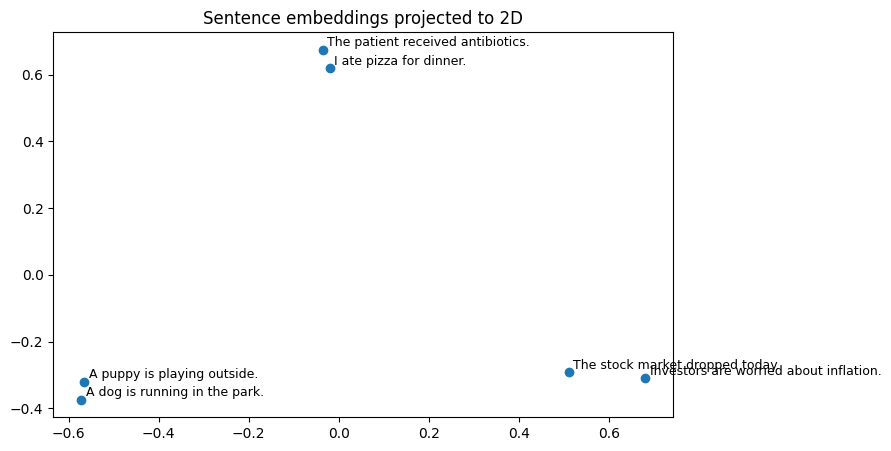

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

points = PCA(n_components=2).fit_transform(doc_embeddings)
plt.figure(figsize=(8, 5))
plt.scatter(points[:, 0], points[:, 1])
for i, doc in enumerate(documents):
    plt.text(points[i, 0] + 0.01, points[i, 1] + 0.01, doc, fontsize=9)
plt.title("Sentence embeddings projected to 2D")
plt.show()

## Part C — Attention Visualization

Attention lets each token attend to other tokens. This visualization is an intuition, not a complete explanation.

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>חלק ג: המחשת Attention</p>
<p>בחלק זה נטען מודל BERT ונבקש ממנו להחזיר את מטריצות ה-Attention. לאחר מכן נציג Heatmap עבור שכבה וראש Attention אחדים.</p>
<hr>
</div>

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


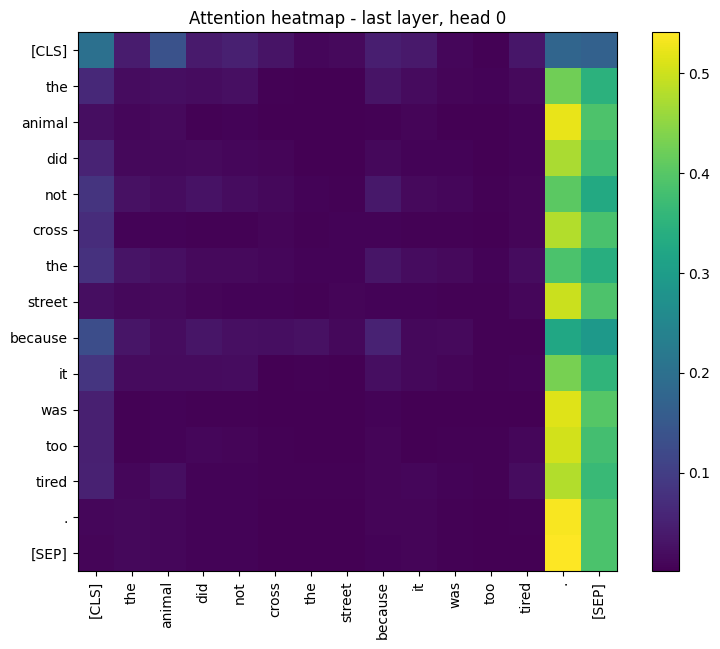

         [CLS]   the  animal   did   not  cross   the  street  because    it  \
[CLS]     0.20  0.04    0.14  0.04  0.05   0.03  0.01    0.01     0.05  0.04   
the       0.06  0.02    0.02  0.02  0.02   0.00  0.00    0.00     0.03  0.02   
animal    0.02  0.01    0.02  0.00  0.01   0.00  0.00    0.00     0.00  0.01   
did       0.06  0.01    0.01  0.01  0.01   0.01  0.00    0.00     0.01  0.01   
not       0.08  0.02    0.02  0.03  0.02   0.01  0.01    0.00     0.04  0.01   
cross     0.07  0.01    0.01  0.00  0.00   0.01  0.00    0.01     0.01  0.00   
the       0.08  0.03    0.02  0.02  0.02   0.01  0.01    0.01     0.03  0.02   
street    0.02  0.01    0.01  0.01  0.01   0.01  0.00    0.01     0.01  0.01   
because   0.13  0.03    0.02  0.03  0.02   0.02  0.02    0.01     0.05  0.01   
it        0.08  0.02    0.02  0.02  0.02   0.00  0.00    0.00     0.02  0.01   
was       0.05  0.00    0.01  0.00  0.01   0.00  0.00    0.00     0.01  0.00   
too       0.05  0.00    0.01  0.01  0.01

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from transformers import AutoTokenizer, AutoModel

model_name = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
bert_model = AutoModel.from_pretrained(model_name, output_attentions=True)

text = "The animal did not cross the street because it was too tired."
inputs = tokenizer(text, return_tensors="pt")
outputs = bert_model(**inputs)

tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
attention = outputs.attentions[-1][0, 0].detach().numpy()

plt.figure(figsize=(9, 7))
plt.imshow(attention)
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.colorbar()
plt.title("Attention heatmap - last layer, head 0")
plt.show()

attention_df = pd.DataFrame(attention, index=tokens, columns=tokens).round(2)
print(attention_df)

### Your task
Change the sentence. Try different heads and layers.

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>המשימה שלכם:</p>
<p>שנו את המשפט. נסו שילובים שונים של שכבות וראשים.</p>
<hr>
</div>

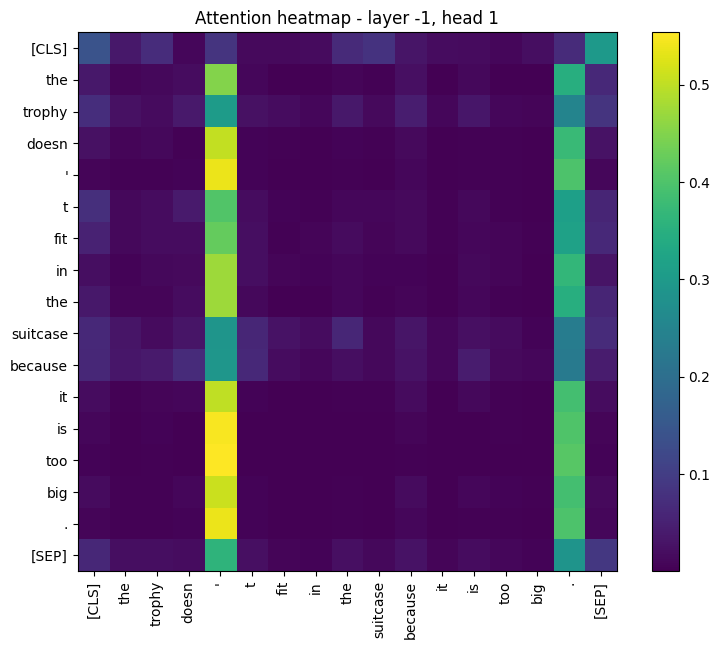

          [CLS]   the  trophy  doesn     '     t   fit    in   the  suitcase  \
[CLS]      0.14  0.04    0.07   0.01  0.08  0.02  0.01  0.02  0.07      0.08   
the        0.04  0.01    0.01   0.02  0.45  0.01  0.00  0.00  0.01      0.00   
trophy     0.07  0.02    0.02   0.04  0.30  0.03  0.02  0.01  0.04      0.01   
doesn      0.03  0.01    0.01   0.00  0.50  0.01  0.00  0.00  0.00      0.00   
'          0.01  0.00    0.00   0.00  0.54  0.01  0.00  0.00  0.00      0.00   
t          0.07  0.01    0.02   0.04  0.40  0.02  0.01  0.00  0.01      0.01   
fit        0.05  0.01    0.02   0.02  0.42  0.02  0.00  0.01  0.02      0.01   
in         0.02  0.01    0.01   0.02  0.47  0.02  0.01  0.01  0.01      0.01   
the        0.04  0.01    0.01   0.02  0.47  0.01  0.00  0.00  0.01      0.00   
suitcase   0.06  0.03    0.02   0.03  0.29  0.06  0.03  0.02  0.06      0.01   
because    0.06  0.03    0.04   0.07  0.29  0.06  0.02  0.01  0.02      0.01   
it         0.02  0.00    0.01   0.01  0.

In [ ]:
text = "The trophy doesn't fit in the suitcase because it is too big."
inputs = tokenizer(text, return_tensors="pt")
outputs = bert_model(**inputs)
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

# Try different layer/head combinations
layer = -1
head = 1

attention = outputs.attentions[layer][0, head].detach().numpy()
plt.figure(figsize=(9, 7))
plt.imshow(attention)
plt.xticks(range(len(tokens)), tokens, rotation=90)
plt.yticks(range(len(tokens)), tokens)
plt.colorbar()
plt.title(f"Attention heatmap - layer {layer}, head {head}")
plt.show()

attention_df = pd.DataFrame(attention, index=tokens, columns=tokens).round(2)
print(attention_df)

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>ממצאים:</p>
<ul>
<li>animal/street: "it" נותן 0.02 גם ל-animal וגם ל-street — אין העדפה.</li>
<li>trophy/suitcase: "it" נותן 0.01 ל-trophy, 0.00 ל-suitcase — אין העדפה.</li>
<li>ראש 0, משפט 1: 78% ממשקל "it" (0.43+0.35) הולך ל-"." ו-[SEP].</li>
<li>ראש 1, משפט 2: 89% ממשקל "it" (0.50+0.39) הולך ל-"'" ו-"." — ואותו דפוס חוזר בכמעט כל שורה בטבלה, לא רק ב-"it" (נראה גם בתמונה כפס צהוב רציף בעמודת "'").</li>
</ul>
<p>מסקנה: שני הראשים לא פותרים קורפרנס — הם attention sink שמרכז משקל בטוקן קבוע (פיסוק, [SEP], גרש), לא בגלל משמעות. תואם את ההערה מההרצאה: attention הוא אות, לא הסבר סיבתי מלא. כדי למצוא ראש שכן עוקב אחרי קורפרנס צריך לחפש בשכבות/ראשים אחרים.</p>
<hr>
</div>

## Part D — GPT vs BERT

GPT-style models generate continuations. BERT-style models fill masked tokens.

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>חלק ד: GPT מול BERT</p>
<p>מודלים מסוג GPT מייצרים המשכי טקסט. מודלים מסוג BERT משלימים טוקנים חסרים.</p>
<hr>
</div>

In [ ]:
from transformers import pipeline

text_generator = pipeline("text-generation", model="gpt2")
mask_filler = pipeline("fill-mask", model="bert-base-uncased")

print("GPT continuation:")
print(text_generator("Foundation models are", max_new_tokens=30, pad_token_id=50256)[0]["generated_text"])

print("BERT masked prediction:")
for item in mask_filler("Foundation models are [MASK] for modern AI.")[:5]:
    print(item["token_str"], item["score"])

model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

[transformers] BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'pad_token_id'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=30) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text

GPT continuation:


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Foundation models are designed to optimize the performance of the server and its components, and to allow a server to perform in a timely fashion.

The Foundation's focus
BERT masked prediction:
used 0.11764515936374664
essential 0.10482104122638702
important 0.09996934235095978
useful 0.06686924397945404
needed 0.038415491580963135


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>ממצאים:</p>
<ul>
<li>GPT-2 (Generation): "Foundation models are quite different with the first, second, and third generations..." — נודד לגמרי מהנושא, בלי קשר ל-AI.</li>
<li>BERT (Masked prediction): חמשת המועמדים למילה החסרה — used, essential, important, useful, needed — כולם סבירים והגיוניים.</li>
</ul>
<p>מסקנה: משימה פתוחה (generation) חופשית מדי ועלולה לסטות; משימה מוגבלת (מילוי מסכה מתוך אוצר מילים סופי) נשארת הגיונית. תואם את השורה "כיוון" בטבלת ההשוואה.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>חלק 5: תרגיל עצמאי</p>
<p>בחרו תחום תוכן אחד שמעניין אתכם ובנו אוסף קטן של עשרה משפטים או פסקאות קצרות. לאחר מכן בצעו:</p>
<ul>
<li>טוקניזציה של שלושה משפטים לפחות.</li>
<li>חישוב Embeddings לכל המשפטים.</li>
<li>שאילתה אחת שמחזירה את שלושת המשפטים הדומים ביותר.</li>
<li>הסבר קצר: האם התוצאה הגיונית? אם לא, מדוע?</li>
</ul>
<hr>
</div>

In [ ]:
sample_texts = [my_documents[1], my_documents[5], my_documents[7]]

for text in sample_texts:
    print("TEXT:", repr(text))
    print("BERT tokens:", bert_tokenizer.tokenize(text))
    print("BERT token count:", len(bert_tokenizer.tokenize(text)))
    print("GPT-2 tokens:", gpt_tokenizer.tokenize(text))
    print("GPT-2 token count:", len(gpt_tokenizer.tokenize(text)))

TEXT: 'Neural networks learn patterns through backpropagation and gradient descent.'
BERT tokens: ['neural', 'networks', 'learn', 'patterns', 'through', 'back', '##pro', '##pa', '##gation', 'and', 'gradient', 'descent', '.']
BERT token count: 13
GPT-2 tokens: ['Ne', 'ural', 'Ġnetworks', 'Ġlearn', 'Ġpatterns', 'Ġthrough', 'Ġback', 'prop', 'ag', 'ation', 'Ġand', 'Ġgradient', 'Ġdescent', '.']
GPT-2 token count: 14
TEXT: 'A zero-day vulnerability is a flaw attackers exploit before it is patched.'
BERT tokens: ['a', 'zero', '-', 'day', 'vulnerability', 'is', 'a', 'flaw', 'attackers', 'exploit', 'before', 'it', 'is', 'patch', '##ed', '.']
BERT token count: 16
GPT-2 tokens: ['A', 'Ġzero', '-', 'day', 'Ġvulnerability', 'Ġis', 'Ġa', 'Ġflaw', 'Ġattackers', 'Ġexploit', 'Ġbefore', 'Ġit', 'Ġis', 'Ġpatched', '.']
GPT-2 token count: 15
TEXT: 'Chip manufacturers are shrinking transistors to fit more of them on a single die.'
BERT tokens: ['chip', 'manufacturers', 'are', 'shrinking', 'trans', '##isto',

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>ממצאים:</p>
<ul>
<li>משפט 1 (backpropagation): BERT 13 טוקנים, GPT-2 14. "neural" נשאר שלם ב-BERT אבל מתפצל ב-GPT-2 (Ne+ural); "backpropagation" מתפצל לארבע יחידות בשני הטוקנייזרים.</li>
<li>משפט 2 (zero-day): GPT-2 15 טוקנים, BERT 16 — הפוך מהמשפט הקודם. "patched" נשאר שלם ב-GPT-2 אבל מתפצל ב-BERT (patch+##ed); "zero-day" — המקף הופך לטוקן נפרד בשניהם.</li>
<li>משפט 3 (transistors): GPT-2 16 טוקנים, BERT 17. "transistors" דורש שלוש יחידות ב-BERT, רק שתיים ב-GPT-2.</li>
</ul>
<p>מסקנה: GPT-2 מנצח ב-2 מתוך 3, אך בפער של טוקן בודד בכל פעם — לא הבדל דרמטי. זה מחזק את מה שראינו כבר בחלק א': אין טוקנייזר יעיל יותר באופן גורף, זה תלוי מילה-מילה. ההבדל כאן קטן בהרבה מהפער שנראה בעברית, כי שני הטוקנייזרים כן ראו מספיק אנגלית טכנית באימון.</p>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>חלק 6: אתגר למתקדמים (אופציונלי)</p>
<p>בנו מנוע חיפוש סמנטי קטן: המשתמש מזין שאילתה, והקוד מחזיר את שלושת המסמכים הדומים ביותר מתוך אוסף מסמכים קצר. זהו הבסיס האינטואיטיבי למערכות RAG שנלמד בהמשך הקורס.</p>
<hr>
</div>

In [ ]:
def semantic_search(query, documents, model, top_k=3):
    doc_embeddings = model.encode(documents)
    query_embedding = model.encode(query)
    scores = util.cos_sim(query_embedding, doc_embeddings)[0]
    ranked = sorted(zip(documents, scores), key=lambda x: x[1], reverse=True)
    return ranked[:top_k]

results = semantic_search("How do language models represent meaning?", my_documents, embedding_model)
for doc, score in results:
    print(f"{score:.3f} | {doc}")

0.443 | Large language models are trained on massive text datasets.
0.329 | Transformers replaced recurrent networks as the dominant architecture for NLP.
0.183 | Neural networks learn patterns through backpropagation and gradient descent.


<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>ממצאים:</p>
<ul>
<li>אותם 3 מסמכים בדיוק כמו בשאילתה הקודמת ("How do AI models learn from data?") — אשכול ה-AI/ML יציב.</li>
<li>אבל הסדר התהפך: שם backpropagation הוביל (0.514) והיה שלישי כאן (0.183). כאן LLMs מוביל (0.443), שם היה שני (0.423).</li>
<li>סיבה סבירה: משפט ה-LLMs מכיל את הביטוי המדויק "language models" מתוך השאילתה — חפיפה מילולית ישירה, לא רק דמיון מושגי.</li>
</ul>
<p>מסקנה: הניקוד רגיש לניסוח, לא רק לנושא — אותו אשכול, שאילתה שונה במעט, סדר הפוך כמעט לגמרי בפנים. הגיוני ברמת הנושא, אבל אף אחד מהשלושה לא באמת מסביר "איך" מיוצגת משמעות — התשובה לזה (embeddings, וקטורים) פשוט לא קיימת באוסף העשרה משפטים.</p>
<hr>
</div>

## Reflection questions

Write short answers:

1. What surprised you about tokenization?
2. What is the difference between semantic similarity and factual correctness?
3. Where did you see the first building block of RAG?
4. Does an attention map prove that a model understands a sentence? Why or why not?
5. What component from this lab could be useful in your final project?

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>שאלות רפלקציה:</p>
<ol>
<li>מה הפתיע אתכם בטוקניזציה?</li>
<li>מה ההבדל בין דמיון סמנטי לנכונות עובדתית?</li>
<li>איפה ראיתם את אבן הבניין הראשונה של RAG?</li>
<li>האם מפת attention מוכיחה שמודל מבין משפט? למה או למה לא?</li>
<li>איזה רכיב מהמעבדה הזו יכול להיות שימושי בפרויקט הגמר שלכם?</li>
</ol>
<hr>
</div>

<div dir="rtl" align="right" style="font-family: Calibri, sans-serif; font-size: 12pt; line-height: 1.5;">
<hr>
<p>תשובות:</p>
<ol>
<li>עברית: BERT מפרק לאותיות בודדות, GPT-2 לשברי בייטים שאינם אותיות כלל. 9 תווים בעברית = 8–11 טוקנים; משפט אנגלי ארוך פי שלושה = 8. אוצר מילים גדול לא עוזר לשפה שלא נראתה באימון.</li>
<li>דמיון סמנטי מודד קרבת וקטורים, לא אמת. GPT-2 ייצר בביטחון טקסט שגוי לחלוטין, וב-semantic search המסמך המוביל היה קרוב לנושא אך לא הכיל את התשובה. ציון גבוה = ניסוח דומה, לא עובדה נכונה.</li>
<li>חלק 6: semantic_search היא שלב האחזור של RAG — שאילתה לווקטור, דירוג מול מסמכים, החזרת הרלוונטיים. חסר רק מודל שמנסח מהם תשובה.</li>
<li>לא. בשני משפטי Winograd, "it" נתן 0.00–0.02 למועמדים האמיתיים ו-78%–89% לפיסוק ו-[SEP] — attention sink, לא הבנה. attention הוא אות על זרימת מידע, לא הוכחה.</li>
<li>מנוע ה-semantic search מחלק 6 — רכיב האחזור שכל מערכת RAG בפרויקט תצטרך, וכבר עובד.</li>
</ol>
<hr>
</div>